![image.png](https://i.imgur.com/a3uAqnb.png)

Epoch 1/5, Loss: 1.0651
Epoch 2/5, Loss: 0.6374
Epoch 3/5, Loss: 0.5189
Epoch 4/5, Loss: 0.4615
Epoch 5/5, Loss: 0.4307

Test Accuracy: 86.21%


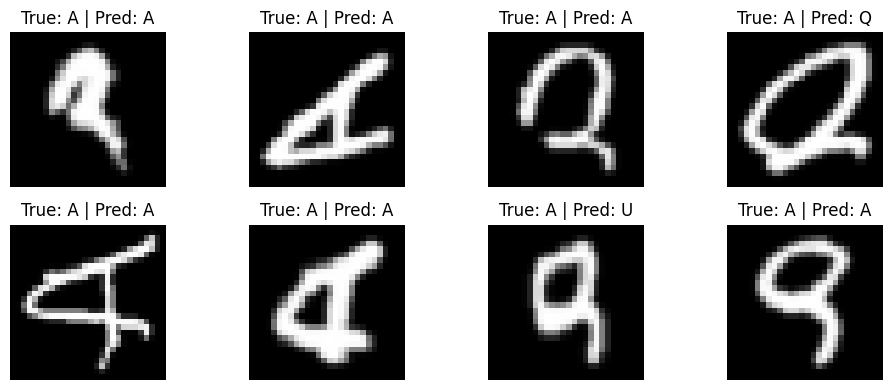

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # normalize grayscale
])

train_data = datasets.EMNIST(root="data", split="letters", train=True, download=True, transform=transform)
test_data  = datasets.EMNIST(root="data", split="letters", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=128, shuffle=False)

class LetterClassifier(nn.Module):
    def __init__(self):
        super(LetterClassifier, self).__init__()
        self.fc1 = nn.Linear(28*28, 100)  # 784 → 100 hidden, nn.Linear has two parameters (first param>size of input, second> size of output)
        self.fc2 = nn.Linear(100, 26)     # 100 → 26 letters (A–Z)

    def forward(self, x):
      # input is image (28 by 28) >> convert the image into a linear feature vector.
        # x = nn.Flatten()(x)     # flatten image
        x = x.view(-1, 28*28)   # flatten image
        x = F.relu(self.fc1(x))
        x = self.fc2(x)         # logits
        return x

model = LetterClassifier()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        # EMNIST letters labels go from 1–26, so subtract 1 to make them 0–25
        labels = labels - 1

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        labels = labels - 1  # adjust label range
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item() # [[25]] > 25

print(f"\nTest Accuracy: {100 * correct / total:.2f}%")

classes = [chr(i) for i in range(65, 91)]  # A-Z

def imshow(img, label, pred):
    img = img.squeeze().numpy()
    plt.imshow(img, cmap="gray")
    plt.title(f"True: {classes[label]} | Pred: {classes[pred]}")
    plt.axis("off")

dataiter = iter(test_loader)
images, labels = next(dataiter)
labels = labels - 1
outputs = model(images)
_, preds = torch.max(outputs, 1)

plt.figure(figsize=(10,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    imshow(images[i], labels[i].item(), preds[i].item())
plt.tight_layout()
plt.show()


# Computing No. of parameters for different sizes of images

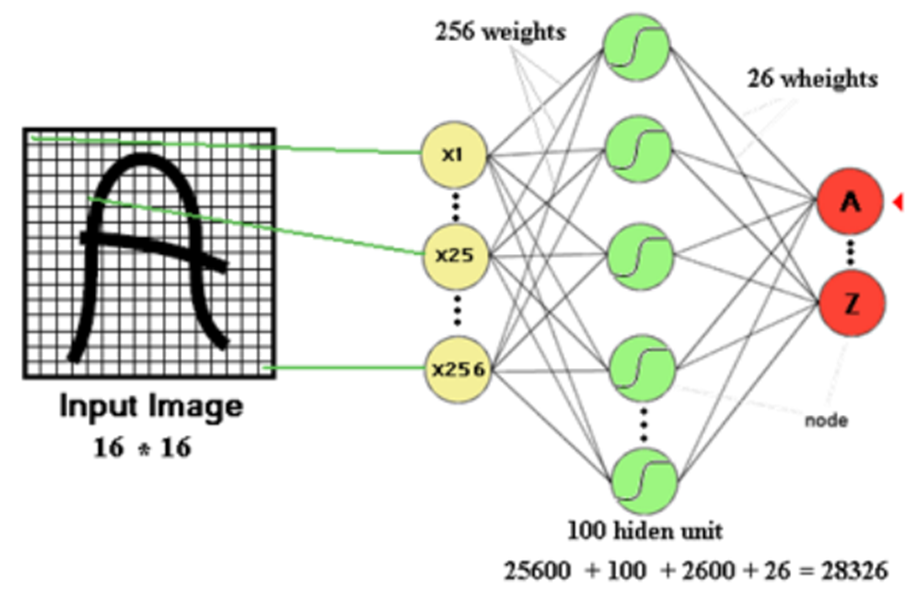

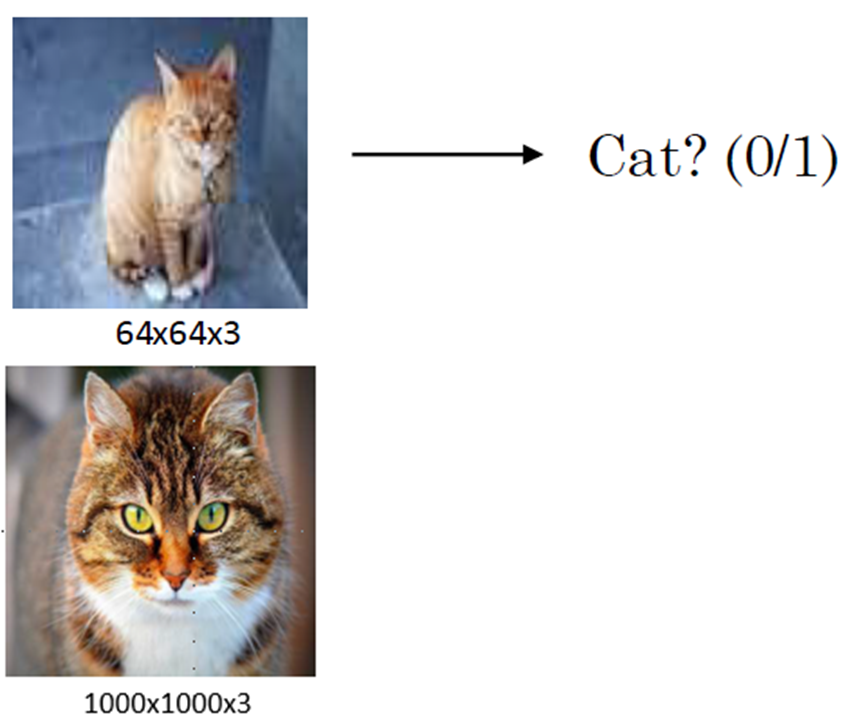

In [11]:
def compute_fc_parameters(input_shape, hidden_units=100, output_units=26):
    input_size = 1
    for dim in input_shape:
        input_size *= dim

    # Input to hidden: weights + biases
    input_hidden_weights = input_size * hidden_units
    input_hidden_biases = hidden_units

    # Hidden to output: weights + biases
    hidden_output_weights = hidden_units * output_units
    hidden_output_biases = output_units

    total_params = input_hidden_weights + input_hidden_biases + hidden_output_weights + hidden_output_biases

    print(f"Input shape: {input_shape}")
    print(f"  Flattened input size: {input_size}")
    print(f"  Input → Hidden: {input_hidden_weights} weights + {input_hidden_biases} biases")
    print(f"  Hidden → Output: {hidden_output_weights} weights + {hidden_output_biases} biases")
    print(f" Total parameters: {total_params:,}\n")


# Examples
compute_fc_parameters((16, 16))
compute_fc_parameters((28, 28))
compute_fc_parameters((64, 64, 3))
compute_fc_parameters((1000, 1000, 3))


Input shape: (16, 16)
  Flattened input size: 256
  Input → Hidden: 25600 weights + 100 biases
  Hidden → Output: 2600 weights + 26 biases
 Total parameters: 28,326

Input shape: (28, 28)
  Flattened input size: 784
  Input → Hidden: 78400 weights + 100 biases
  Hidden → Output: 2600 weights + 26 biases
 Total parameters: 81,126

Input shape: (64, 64, 3)
  Flattened input size: 12288
  Input → Hidden: 1228800 weights + 100 biases
  Hidden → Output: 2600 weights + 26 biases
 Total parameters: 1,231,526

Input shape: (1000, 1000, 3)
  Flattened input size: 3000000
  Input → Hidden: 300000000 weights + 100 biases
  Hidden → Output: 2600 weights + 26 biases
 Total parameters: 300,002,726



In [12]:
# !pip install fvcore
# ptflops
from fvcore.nn import FlopCountAnalysis, parameter_count_table
import torch

# efficiency of the model > calculate it based on the number of floating point operations
# 0.2 * 0.345 >>> 1 FLOPS

input_tensor = torch.randn(1, 1, 28, 28)

flops = FlopCountAnalysis(model, input_tensor)
print(f"Total FLOPs: {flops.total():,}")
print("\nDetailed FLOPs per layer:")
print(flops.by_module())

print("\nParameter Count:")
print(parameter_count_table(model))

Total FLOPs: 81,000

Detailed FLOPs per layer:
Counter({'': 81000, 'fc1': 78400, 'fc2': 2600})

Parameter Count:
| name         | #elements or shape   |
|:-------------|:---------------------|
| model        | 81.1K                |
|  fc1         |  78.5K               |
|   fc1.weight |   (100, 784)         |
|   fc1.bias   |   (100,)             |
|  fc2         |  2.6K                |
|   fc2.weight |   (26, 100)          |
|   fc2.bias   |   (26,)              |
